<a href="https://colab.research.google.com/github/DrDourado/ME_615_Spring_2026/blob/main/ME_615_Parametric_Classification_Spring_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Objective:** Demonstrate basic parametric classification concepts using the Iris dataset.

This notebook aims to explore binary classification techniques using the well-known Iris dataset. We will start by classifying based on a single feature and then extend our approach to two features. For each scenario, we will implement decision rules/classifiers, visualize their decision boundaries, and thoroughly evaluate their performance using key classification metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix. Finally, we will generate Receiver Operating Characteristic (ROC) curves with Area Under the Curve (AUC) scores to further understand the classifiers' capabilities.

The Iris dataset is a classic and very popular dataset in machine learning and statistics. It contains 150 samples of iris flowers, with 50 samples from each of three species: Iris setosa, Iris versicolor, and Iris virginica. Each sample has four features:

*   **Sepal Length (cm)**
*   **Sepal Width (cm)**
*   **Petal Length (cm)**
*   **Petal Width (cm)**

The goal of classification tasks with this dataset is typically to predict the species of an iris flower based on these four measurements. In this notebook, we will focus on binary classification by selecting two of these three species for our analysis at each step.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import seaborn as sns

from sklearn import datasets

from sklearn.linear_model import SGDClassifier, LogisticRegression, Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from scipy.optimize import minimize

from sklearn.metrics import mean_squared_error
from sklearn.metrics import log_loss

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

import matplotlib as mpl
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

np.random.seed(42)

Auxiliary functions

In [2]:
# function to automatically save generated figures (credit to Aurelien Geron "Hands-On Machine Learning with Scikit-Learn & Tensorflow")
ROOT_DIR = "."
IMAGES_PATH = os.path.join(ROOT_DIR, "images")
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

**Loading and Exploring the Dataset**

* The Iris dataset contains features (sepal & petal length/width) for three flower species.
* We convert it into a binary classification problem (Flower X vs. Non-Flower X).

In [3]:
iris = datasets.load_iris()

print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

### Understanding Binary Classification and Feature Selection

**Binary Classification** is a type of supervised learning where the goal is to classify elements into one of two categories (classes). In our case, we've transformed the original three-class Iris dataset into a binary problem: classifying 'Iris setosa' (represented by `0`) versus 'non-Iris setosa' (which includes 'Iris versicolor' and 'Iris virginica', both represented by `1`). This simplification allows us to focus on distinguishing between the most separable class and the rest.

**Feature Selection** is the process of choosing a subset of relevant features (variables, predictors) for use in model construction. The goal is to improve prediction accuracy or to improve the understanding of the model. For this initial binary classification task, we have selected a single feature: **Petal Length**. This choice is often made based on domain knowledge, exploratory data analysis, or for simplicity in demonstrating basic classification concepts. Petal length is known to be a strong differentiator (high correlation metrics) for Iris setosa from the other two species.

In [4]:
iris_data = iris.data
iris_target = iris.target

binary_target = np.where(iris_target == 0, 0, 1)

petal_length = iris_data[:, 2]

print(f"Original Iris target first 5 values: {iris_target[:5]}")
print(f"Binary target first 5 values: {binary_target[:5]}\n")

print(f"Original Iris target last 5 values: {iris_target[-5:]}")
print(f"Binary target last 5 values: {binary_target[-5:]}\n")

print(f"Petal length first 5 values: {petal_length[:5]}")
print(f"Shape of petal_length: {petal_length.shape}")

Original Iris target first 5 values: [0 0 0 0 0]
Binary target first 5 values: [0 0 0 0 0]

Original Iris target last 5 values: [2 2 2 2 2]
Binary target last 5 values: [1 1 1 1 1]

Petal length first 5 values: [1.4 1.4 1.3 1.5 1.4]
Shape of petal_length: (150,)


### Decision Rules and Decision Boundaries

A **decision rule** is a criterion or set of criteria used by a classifier to assign an input data point to one of several classes. In the simplest form of binary classification with a single feature, a decision rule often takes the form of a **threshold**.

In our current scenario, we are classifying Iris flowers into two categories: 'Setosa' (Class 0) and 'Non-Setosa' (Class 1) based solely on their **Petal Length**.

An illustrative decision rule is:

*   If `Petal Length <= 2.5 cm`, then classify as **Setosa (Class 0)**.
*   If `Petal Length > 2.5 cm`, then classify as **Non-Setosa (Class 1)**.

The value `2.5 cm` is our **decision threshold**. This threshold acts as a **decision boundary** in our one-dimensional feature space. All data points (petal lengths) falling on one side of this boundary are assigned to one class, and all points on the other side are assigned to the second class.

Visually, this boundary appears as a vertical line on our 1D plot. The objective of setting this threshold is to separate the classes as effectively as possible, minimizing misclassifications. We observed that Setosa flowers generally have much shorter petal lengths (up to 1.9 cm) compared to Non-Setosa flowers (starting from 3.0 cm), making a threshold in this range (like 2.5 cm) a logical choice for a clear separation.

In [5]:
max_petal_length_setosa = petal_length[binary_target == 0].max()
min_petal_length_non_setosa = petal_length[binary_target == 1].min()

print(f"Maximum petal length for Setosa (class 0): {max_petal_length_setosa} cm")
print(f"Minimum petal length for non-Setosa (class 1): {min_petal_length_non_setosa} cm")

# A suitable threshold would be between 1.9 and 3.0, e.g., 2.5
decision_threshold = 2.5

# Implement the decision rule
predictions_one_feature = np.where(petal_length <= decision_threshold, 0, 1)

print(f"\nDecision threshold set at: {decision_threshold} cm")
print(f"First 10 actual binary targets: {binary_target[:10]}")
print(f"First 10 predictions (one feature): {predictions_one_feature[:10]}")
print(f"Last 10 actual binary targets: {binary_target[-10:]}")
print(f"Last 10 predictions (one feature): {predictions_one_feature[-10:]}")

Maximum petal length for Setosa (class 0): 1.9 cm
Minimum petal length for non-Setosa (class 1): 3.0 cm

Decision threshold set at: 2.5 cm
First 10 actual binary targets: [0 0 0 0 0 0 0 0 0 0]
First 10 predictions (one feature): [0 0 0 0 0 0 0 0 0 0]
Last 10 actual binary targets: [1 1 1 1 1 1 1 1 1 1]
Last 10 predictions (one feature): [1 1 1 1 1 1 1 1 1 1]


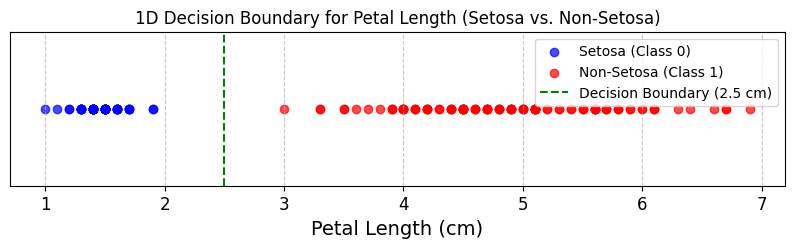

Saving figure decision_boundary_1d


<Figure size 640x480 with 0 Axes>

In [6]:
plt.figure(figsize=(10, 2))
plt.scatter(petal_length[binary_target == 0], np.zeros(np.sum(binary_target == 0)), color='blue', label='Setosa (Class 0)', alpha=0.7)
plt.scatter(petal_length[binary_target == 1], np.zeros(np.sum(binary_target == 1)), color='red', label='Non-Setosa (Class 1)', alpha=0.7)

plt.axvline(x=decision_threshold, color='green', linestyle='--', label=f'Decision Boundary ({decision_threshold} cm)')

plt.xlabel('Petal Length (cm)')
plt.yticks([]) # Hide y-axis ticks for 1D visualization
plt.title('1D Decision Boundary for Petal Length (Setosa vs. Non-Setosa)')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
save_fig("decision_boundary_1d")

### Classification Metrics and Model Performance

Classifier metrics quantify **how well a model makes decisions**, not just how often it is correct.
Different metrics emphasize different types of errors, which is critical in engineering systems
where false positives and false negatives may have unequal consequences.

- **Accuracy** measures overall correctness but can be misleading with imbalanced data.
- **Precision** quantifies how reliable positive predictions are.
- **Recall** measures the ability to detect true positives.
- **F1-score** balances precision and recall when trade-offs matter.
- **Confusion Matrix** exposes the types of errors being made.
- **ROC Curve / AUC** evaluate performance across all decision thresholds.

Selecting appropriate metrics ensures that model evaluation aligns with **risk, safety, and decision-making requirements**, rather than raw prediction counts.

---

How to evaluate how good my classier is?

Example: How is it doing on dog vs no-dog?

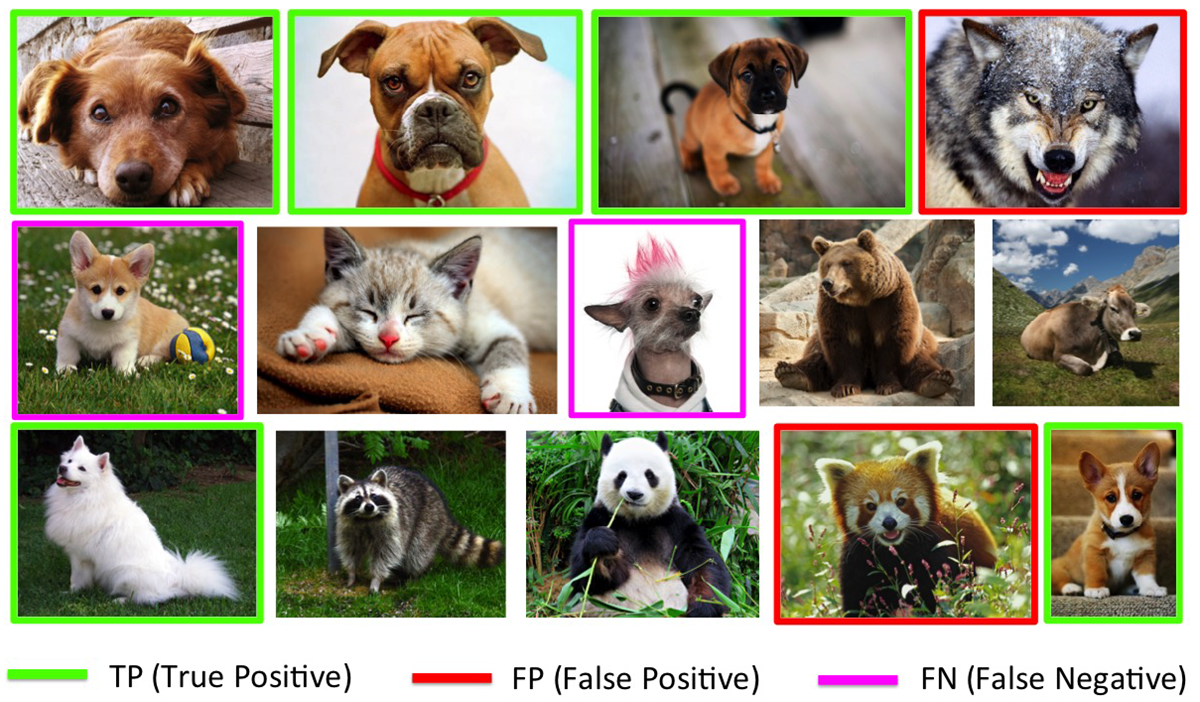


---

**Accuracy** is one of the most straightforward and commonly used evaluation metrics for classification models. It measures the proportion of correctly classified instances (both true positives and true negatives) out of the total number of instances.

The formula for Accuracy is:

$$\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$


An accuracy of 1.0 (or 100%) indicates that applied decision rule and related decision boundary, correctly classified every single instance in the dataset. This means there were no false positives or false negatives when distinguishing between 'classes' using the chosen threshold. While very high accuracy can be good, it's important to remember that for imbalanced datasets or specific problems, other metrics might provide a more nuanced view of performance.

---

**Precision** measures the proportion of positive identifications that were actually correct. It answers the question: "Of all the instances our model predicted as positive, how many actually were positive?" High precision relates to a low false positive rate.

The formula for Precision is:

$$\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}} = \frac{TP}{TP + FP}$$

A precision of 1.0 (or 100%) for Class 0 (e.g., dog, or Setosa flower) means that when our model predicted an instance as '0', it was always correct. There were no false positives; that is, no '1' instances incorrectly classified as '0'. This indicates a perfect performance in terms of avoiding incorrect positive predictions for the class.

---

**Recall** (also known as Sensitivity or True Positive Rate) measures the proportion of actual positives that were correctly identified by the model. It answers the question: "Of all the actual positive instances, how many did our model correctly identify?" High recall relates to a low false negative rate.

The formula for Recall is:

$$\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}} = \frac{TP}{TP + FN}$$

A recall of 1.0 (or 100%) for Class 0 (e.g., dog, or Setosa flower) means that our model successfully identified all actual '0' instances. There were no false negatives; that is, no actual '0' instances incorrectly classified as '1'. This indicates a perfect performance in terms of finding all the positive cases for the respective class.

---

The **F1-score** is the harmonic mean of Precision and Recall. It is a single metric that balances both precision and recall, providing a more robust measure of a classifier's performance than accuracy alone, especially on imbalanced datasets. It is particularly useful when you need to seek a balance between Precision and Recall, and an uneven class distribution exists.

The formula for F1-score is:

$$\text{F1-score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

An F1-score of 1.0 (or 100%) for Class 0 (e.g., dog, or Setosa flower) indicates perfect precision and perfect recall. Since both precision and recall were 1.0, their harmonic mean is also 1.0.

---

A **Confusion Matrix** is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm.

It breaks down the predictions into four categories for a binary classification problem:

*   **True Positives (TP)**: The number of instances correctly predicted as the positive class.
*   **True Negatives (TN)**: The number of instances correctly predicted as the negative class.
*   **False Positives (FP)**: The number of instances incorrectly predicted as the positive class (Type I error).
*   **False Negatives (FN)**: The number of instances incorrectly predicted as the negative class (Type II error).

In [7]:
# Calculate Accuracy
accuracy_one_feature = accuracy_score(binary_target, predictions_one_feature)
print(f"\nAccuracy: {accuracy_one_feature:.4f}")

# Calculate Precision (for class 0, Setosa)
precision_one_feature = precision_score(binary_target, predictions_one_feature, pos_label=0)
print(f"Precision (for class 0): {precision_one_feature:.4f}")

# Calculate Recall (for class 0, Setosa)
recall_one_feature = recall_score(binary_target, predictions_one_feature, pos_label=0)
print(f"Recall (for class 0): {recall_one_feature:.4f}")

# Calculate F1-score (for class 0, Setosa)
f1_one_feature = f1_score(binary_target, predictions_one_feature, pos_label=0)
print(f"F1-score (for class 0): {f1_one_feature:.4f}")


Accuracy: 1.0000
Precision (for class 0): 1.0000
Recall (for class 0): 1.0000
F1-score (for class 0): 1.0000


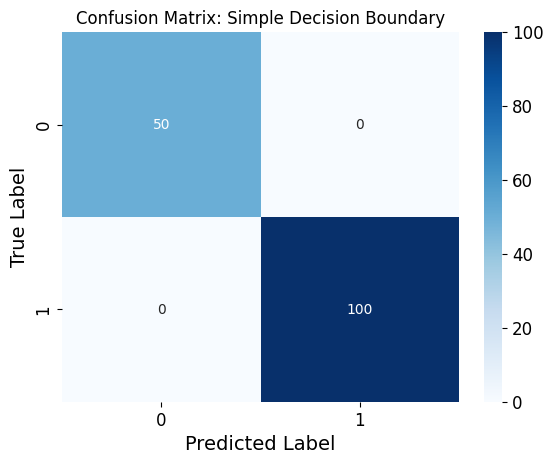

Saving figure confusion_matrix_decision_boundary_1d


<Figure size 640x480 with 0 Axes>

In [8]:
# Calculate Confusion Matrix
conf_matrix_one_feature = confusion_matrix(binary_target, predictions_one_feature)

sns.heatmap(conf_matrix_one_feature, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Simple Decision Boundary")
plt.show()
save_fig("confusion_matrix_decision_boundary_1d")

### Receiver Operating Characteristic (ROC) Curve and AUC

The **Receiver Operating Characteristic (ROC) curve** is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It plots two parameters:

*   **True Positive Rate (TPR)**: Also known as Recall or Sensitivity. It's the proportion of actual positive cases that are correctly identified.
$$ \text{TPR} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$$

*   **False Positive Rate (FPR)**: Also known as Fall-out. It's the proportion of actual negative cases that are incorrectly identified as positive.
$$\text{FPR} = \frac{\text{False Positives}}{\text{False Positives} + \text{True Negatives}}$$

Each point on the ROC curve represents a sensitivity/specificity pair corresponding to a particular decision threshold. A classifier that perfectly separates the classes would have a curve that passes through the top-left corner (0,1) of the plot, indicating 100% TPR and 0% FPR.

The **Area Under the Curve (AUC)** is a scalar value that summarizes the overall performance of a classifier across all possible classification thresholds. AUC ranges from 0 to 1:

*   An AUC of **1.0** indicates a perfect classifier (i.e., it can perfectly distinguish between positive and negative classes).
*   An AUC of **0.5** indicates a classifier performing no better than random guessing.
*   An AUC of **0.0** indicates a perfectly incorrect classifier (i.e., it predicts all positives as negatives and all negatives as positives).

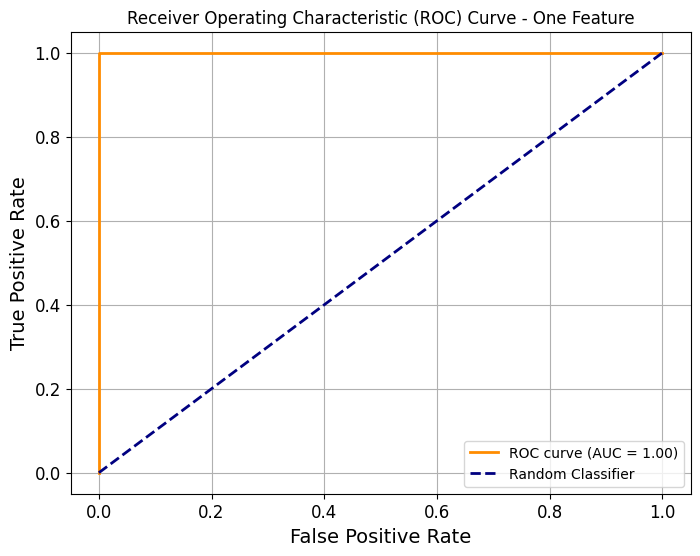

Saving figure roc_curve_one_feature


<Figure size 640x480 with 0 Axes>

In [9]:
# Calculate 'probability' for the positive class (Setosa, class 0)
# Since predictions_one_feature is 0 for Setosa and 1 for Non-Setosa,
# we want a score where 0 means high probability of Setosa (1.0) and 1 means low probability of Setosa (0.0).
# So, if prediction is 0, score is 1; if prediction is 1, score is 0.
# This can be achieved by 1 - predictions_one_feature
y_scores_one_feature = 1 - predictions_one_feature

# Compute FPR, TPR, and thresholds
# pos_label=0 because 'Setosa' (class 0) is considered the positive class
fpr_one_feature, tpr_one_feature, thresholds_one_feature = roc_curve(binary_target, y_scores_one_feature, pos_label=0)

# Calculate AUC
roc_auc_one_feature = auc(fpr_one_feature, tpr_one_feature)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_one_feature, tpr_one_feature, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_one_feature:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - One Feature')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
save_fig("roc_curve_one_feature")

In [10]:
# Print the AUC score
print(f"AUC for one-feature classification: {roc_auc_one_feature:.4f}")

AUC for one-feature classification: 1.0000


**Logistic Classifier**

A logistic classifier is a **parametric probabilistic classifier** that models the probability of a binary outcome as a sigmoid (logistic) function of a linear combination of the input features.  
It assumes that the **log-odds** of the class probability are a linear function of the features.

Mathematically:
$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b),\qquad \sigma(z) = \frac{1}{1 + e^{-z}}$$

where 𝞈 and *b* are model parameters learned from data.

**Decision rule**:
The classifier predicts the positive class when the estimated probability exceeds a threshold (typically 0.5):

$$\hat{y} = \begin{cases} 1, & P(y=1 \mid \mathbf{x}) \ge 0.5 \\ 0, & P(y=1 \mid \mathbf{x}) < 0.5 \end{cases}$$

This threshold can be adjusted to reflect different risk or cost preferences.

---

**Decision boundary**:
The decision boundary is defined by the set of feature values where the model is indifferent between classes:

$$\mathbf{w}^T \mathbf{x} + b = 0$$

- In **one dimension**, this corresponds to a single threshold on the feature value  
- In **two dimensions**, it is a straight line  
- In **higher dimensions**, it is a hyperplane  

The linear form of the boundary reflects the model’s parametric assumptions.


In [11]:
X_log_reg = petal_length.reshape(-1, 1)

log_reg_1d = LogisticRegression(solver="lbfgs", random_state=42)
log_reg_1d.fit(X_log_reg, binary_target)

log_pred_1d = log_reg_1d.predict(X_log_reg)

In [12]:
X_new = np.linspace(0, 5, 1000).reshape(-1, 1)
y_proba = log_reg_1d.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 0] >= 0.5][0]

Saving figure logistic_regression_1d_plot


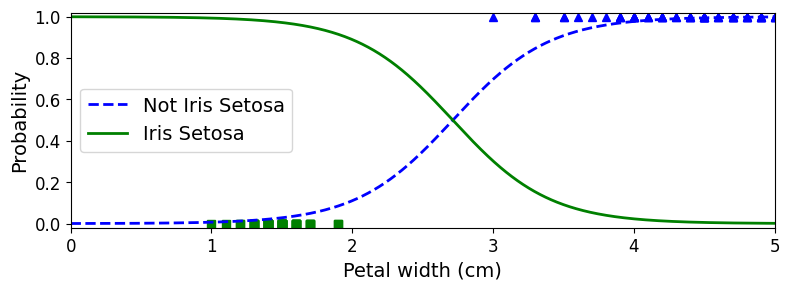

In [13]:
plt.figure(figsize=(8, 3))
plt.plot(petal_length[binary_target==0], binary_target[binary_target==0], "gs")
plt.plot(petal_length[binary_target==1], binary_target[binary_target==1], "b^")
plt.plot(X_new, y_proba[:, 1], "b--", linewidth=2, label="Not Iris Setosa")
plt.plot(X_new, y_proba[:, 0], "g-", linewidth=2, label="Iris Setosa")
plt.xlabel("Petal width (cm)", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.legend(loc="center left", fontsize=14)
plt.axis([0, 5, -0.02, 1.02])
save_fig("logistic_regression_1d_plot")
plt.show()

In [14]:
print("log reg accuracy: "+str(accuracy_score(binary_target, log_pred_1d)*100)+" %")
print("log reg precision: "+str(precision_score(binary_target, log_pred_1d)*100)+" %")
print("log reg recall: "+str(recall_score(binary_target, log_pred_1d)*100)+" %")
print("log reg f1 score: "+str(f1_score(binary_target, log_pred_1d)*100)+" %")

log reg accuracy: 100.0 %
log reg precision: 100.0 %
log reg recall: 100.0 %
log reg f1 score: 100.0 %


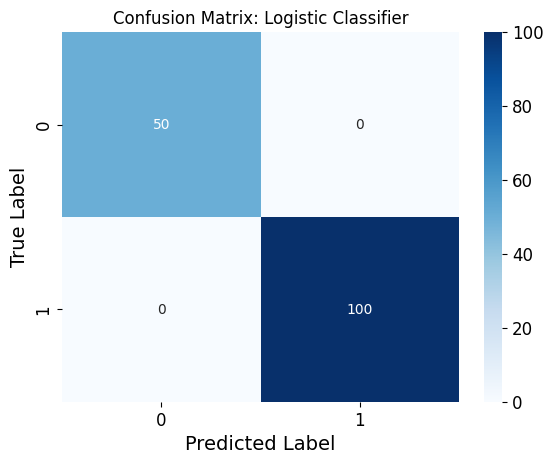

Saving figure log_reg_1D_confusion_matrix


<Figure size 640x480 with 0 Axes>

In [15]:
cm_SGD = confusion_matrix(binary_target, log_pred_1d)

sns.heatmap(cm_SGD, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Logistic Classifier")
plt.show()
save_fig("log_reg_1D_confusion_matrix")

### Binary Classification with Two Features

**Advantages of Using Multiple Features**

In classification problems, leveraging multiple features rather than relying on a single one offers several significant advantages:

1.  **Improved Classification Accuracy**: More features often provide a richer and more comprehensive description of the data points. This additional information can help a classifier make more informed decisions, leading to higher accuracy, especially when individual features alone are not perfectly discriminative. For instance, while 'petal length' alone was excellent for distinguishing 'Setosa' from 'Non-Setosa', it might not be sufficient to perfectly separate 'Versicolor' from 'Virginica'. Combining it with 'petal width' could reveal a clearer separation.

2.  **Handling More Complex Decision Boundaries**: With a single feature, the decision boundary is limited to a simple threshold (a point on a 1D line). When two features are used, the decision boundary can be a line or a curve in a 2D plane, allowing the classifier to separate classes that are not linearly separable in a single dimension. As we move to more features, the decision boundaries can become hyperplanes or more complex surfaces in higher-dimensional spaces, enabling the model to capture intricate relationships within the data.

3.  **Resolving Ambiguity and Overlap**: In cases where different classes overlap significantly when viewed through the lens of a single feature, introducing another relevant feature can help disentangle them. The combination of features might create a separation that was not apparent with just one. For example, two different species might have similar petal lengths, but their petal widths could be distinctly different, thus allowing a classifier to differentiate between them when both features are considered.

4.  **Robustness to Noise**: A classifier relying on multiple features can be more robust to noise or errors in any single feature. If one feature has some erroneous values, the other features can compensate and still provide sufficient information for correct classification.

By moving from one feature to two features, we aim to demonstrate how this increased dimensionality can enhance the classifier's ability to model more complex relationships and potentially achieve better performance for classes that are harder to separate.

---

**Decision Boundaries in 2D**

A **decision boundary** is a hypersurface that partitions the underlying vector space into two or more regions, one for each class. In a binary classification problem, this boundary separates the data points belonging to one class from those belonging to the other.

When we move from a single feature to **two features**, our data points now exist in a two-dimensional space. Consequently, the decision boundary is no longer a single point (threshold) on a line, but rather a **line or a curve** on a 2D plane.

For a **Logistic Regression** classifier, the decision boundary is inherently **linear**. This means that Logistic Regression attempts to find the best-fitting straight line (or a hyperplane in higher dimensions) that separates the two classes. The model calculates a probability score for each data point belonging to the positive class. The decision boundary is defined by the points where this probability equals 0.5. On one side of this line, the probability of belonging to the positive class is greater than 0.5, and on the other side, it is less than 0.5. Mathematically, the decision boundary for a binary Logistic Regression is given by the equation $w_1x_1 + w_2x_2 + b = 0$, where $x_1$ and $x_2$ are the two features (e.g., Petal Length and Petal Width), and $w_1, w_2, b$ are the learned parameters (coefficients and intercept) of the model.

In our visualization, the two distinct colored regions represent the areas where the Logistic Regression model predicts Class 0 (Setosa) or Class 1 (Non-Setosa). The clear line separating these two colors is the linear decision boundary found by the model based on Petal Length and Petal Width. This linear separation is effective here because the 'Setosa' class is well-separated from the 'Non-Setosa' classes by a straight line in the petal length vs. petal width plane.

---

Expanding Analysis to 2 features: petal length (cm) and width (cm)

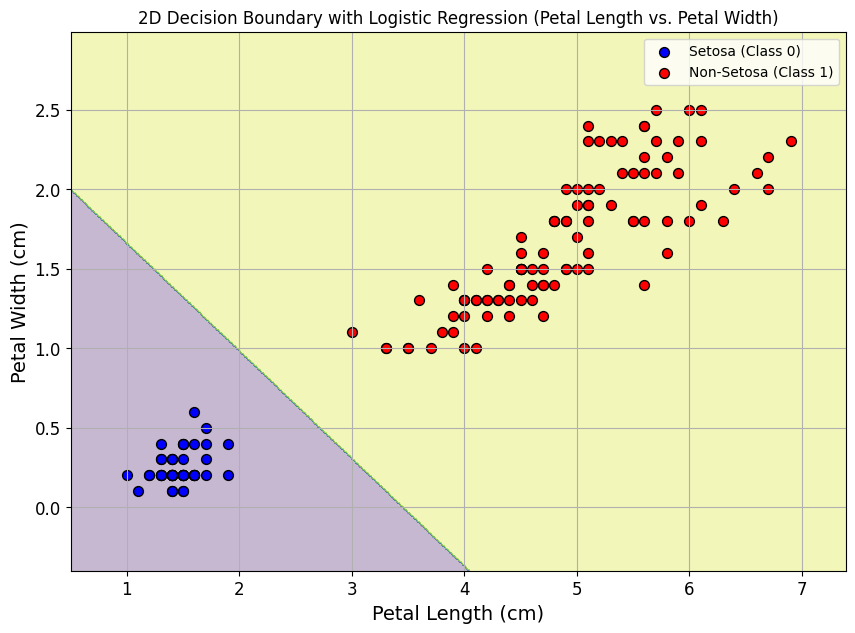

Saving figure log_reg_2D_decision_boundary


<Figure size 640x480 with 0 Axes>

In [16]:
X_two_features = iris_data[:, [2, 3]]


# Instantiate and fit the Logistic Regression model
# Using 'liblinear' solver for binary classification and L1/L2 regularization
# 'C' is the inverse of regularization strength; smaller values specify stronger regularization.
log_reg_model = LogisticRegression(solver='liblinear', random_state=42)
log_reg_model.fit(X_two_features, binary_target)

# Create a meshgrid to plot the decision boundary
x_min, x_max = X_two_features[:, 0].min() - 0.5, X_two_features[:, 0].max() + 0.5
y_min, y_max = X_two_features[:, 1].min() - 0.5, X_two_features[:, 1].max() + 0.5
h = 0.01  # Step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict on the meshgrid points
Z = log_reg_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, levels=np.linspace(0, 1, 10))

# Plot the actual data points
plt.scatter(X_two_features[binary_target == 0, 0], X_two_features[binary_target == 0, 1],
            c='blue', label='Setosa (Class 0)', edgecolors='k', s=50)
plt.scatter(X_two_features[binary_target == 1, 0], X_two_features[binary_target == 1, 1],
            c='red', label='Non-Setosa (Class 1)', edgecolors='k', s=50)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('2D Decision Boundary with Logistic Regression (Petal Length vs. Petal Width)')
plt.legend()
plt.grid(True)
plt.show()
save_fig("log_reg_2D_decision_boundary")

## Classifier Metrics (Two Features)

In [17]:
# 1. Make predictions on the X_two_features data
predictions_two_features = log_reg_model.predict(X_two_features)

# 2. Calculate Confusion Matrix
conf_matrix_two_feature = confusion_matrix(binary_target, predictions_two_features)

# 3. Calculate Accuracy
accuracy_two_feature = accuracy_score(binary_target, predictions_two_features)
print(f"\nAccuracy (Two Features): {accuracy_two_feature:.4f}")

# 4. Calculate Precision (for class 0, Setosa)
precision_two_feature = precision_score(binary_target, predictions_two_features, pos_label=0)
print(f"Precision (Two Features, for class 0): {precision_two_feature:.4f}")

# 5. Calculate Recall (for class 0, Setosa)
recall_two_feature = recall_score(binary_target, predictions_two_features, pos_label=0)
print(f"Recall (Two Features, for class 0): {recall_two_feature:.4f}")

# 6. Calculate F1-score (for class 0, Setosa)
f1_two_feature = f1_score(binary_target, predictions_two_features, pos_label=0)
print(f"F1-score (Two Features, for class 0): {f1_two_feature:.4f}")


Accuracy (Two Features): 1.0000
Precision (Two Features, for class 0): 1.0000
Recall (Two Features, for class 0): 1.0000
F1-score (Two Features, for class 0): 1.0000


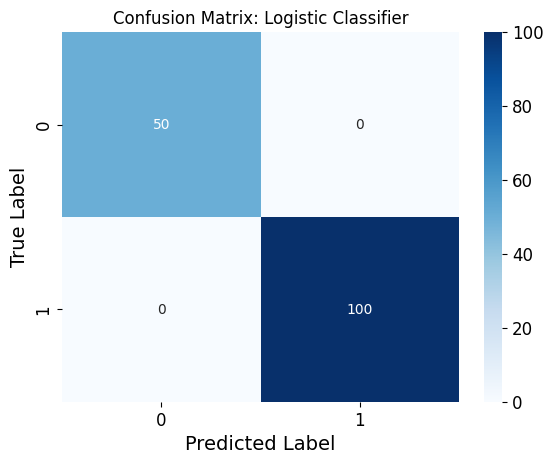

Saving figure log_reg_2D_confusion_matrix


<Figure size 640x480 with 0 Axes>

In [18]:
sns.heatmap(conf_matrix_two_feature, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Logistic Classifier")
plt.show()
save_fig("log_reg_2D_confusion_matrix")

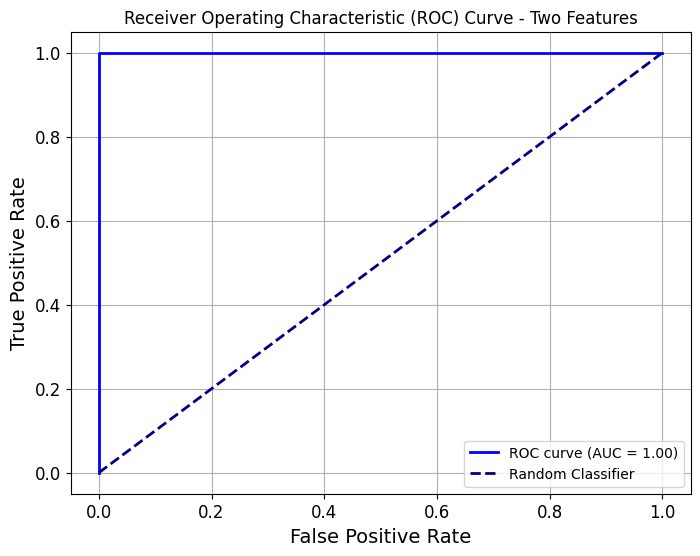

Saving figure roc_curve_two_feature


<Figure size 640x480 with 0 Axes>

In [19]:
# Get probability estimates for the positive class (Setosa, class 0)
# log_reg_model.predict_proba returns probabilities for [class 0, class 1]
# So, we need the first column (index 0) for class 0.
y_scores_two_features = log_reg_model.predict_proba(X_two_features)[:, 0]

# Compute FPR, TPR, and thresholds
# pos_label=0 because 'Setosa' (class 0) is considered the positive class
fpr_two_feature, tpr_two_feature, thresholds_two_feature = roc_curve(binary_target, y_scores_two_features, pos_label=0)

# Calculate AUC
roc_auc_two_feature = auc(fpr_two_feature, tpr_two_feature)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_two_feature, tpr_two_feature, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_two_feature:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Two Features')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
save_fig("roc_curve_two_feature")

In [20]:
# Print the AUC score
print(f"AUC for two-feature classification: {roc_auc_two_feature:.4f}")

AUC for two-feature classification: 1.0000


## Summary:

### Data Analysis Key Findings

*   **Dataset Overview**: The Iris dataset, consisting of 150 samples across three species with four features (sepal length, sepal width, petal length, petal width), was successfully loaded.
*   **One-Feature Binary Classification (Setosa vs. Non-Setosa)**:
    *   A binary classification problem was established by classifying 'Iris setosa' (class 0) against 'non-Iris setosa' (classes 1 and 2, combined into class 1) using only the 'Petal Length' feature.
    *   A simple threshold-based decision rule was implemented: `Petal Length <= 2.5 cm` classifies as 'Setosa', otherwise 'Non-Setosa'. This rule was chosen as the maximum petal length for Setosa was 1.9 cm and the minimum for non-Setosa was 3.0 cm, indicating clear separation.
    *   **Perfect Classification Performance**: The one-feature model achieved flawless performance across all evaluated metrics for separating 'Setosa' from 'Non-Setosa':
        *   **Confusion Matrix**: \[[50 0], \[0 100]] (50 True Positives, 100 True Negatives, 0 False Positives, 0 False Negatives).
        *   **Accuracy**: 1.0
        *   **Precision (for class 0 'Setosa')**: 1.0
        *   **Recall (for class 0 'Setosa')**: 1.0
        *   **F1-score (for class 0 'Setosa')**: 1.0
        *   **Area Under the Curve (AUC)**: 1.0. The ROC curve reached the top-left corner (0,1), confirming perfect discrimination.
*   **Two-Feature Binary Classification (Setosa vs. Non-Setosa)**:
    *   The binary classification problem was extended to use two features: 'Petal Length' and 'Petal Width'.
    *   A Logistic Regression model was employed as a parametric classifier, and its linear decision boundary was successfully visualized in a 2D scatter plot, clearly separating the two classes.
    *   **Identical Perfect Classification Performance**: The two-feature Logistic Regression model also achieved perfect performance, identical to the one-feature case:
        *   **Confusion Matrix**: \[[50 0], \[0 100]]
        *   **Accuracy**: 1.0
        *   **Precision (for class 0 'Setosa')**: 1.0
        *   **Recall (for class 0 'Setosa')**: 1.0
        *   **F1-score (for class 0 'Setosa')**: 1.0
        *   **Area Under the Curve (AUC)**: 1.0.
*   **Comparison**: For the specific binary classification task of separating 'Iris setosa' from 'non-Iris setosa', both the one-feature (Petal Length only) and two-feature (Petal Length and Petal Width) models achieved perfect classification. The addition of 'Petal Width' did not provide incremental performance gain because 'Petal Length' alone was already sufficient for perfect separability.

### Insights or Next Steps

*   The 'Iris setosa' species is perfectly linearly separable from the other two Iris species using petal measurements, making it an excellent candidate for demonstrating basic classification concepts with high confidence.
*   For future analysis, the next step should involve tackling more challenging binary classification problems (e.g., 'Iris versicolor' vs. 'Iris virginica' from the remaining classes, where overlap is known to exist) or extending the analysis to multi-class classification to observe how different features and models handle less separable classes and assess the true benefits of additional features.


# ***Now is your turn!***

In [21]:
# TODO:
# Check what would be the classifiers performance when employing the two features that are no very highly correlated to the output, sepal lenght and width!